<a href="https://colab.research.google.com/github/Angappan95/langchain-practice/blob/main/02_ConditionalGraph.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install langchain langgraph python-dotenv notebook

In [24]:
from typing import TypedDict, Literal

class PortfolioState(TypedDict):
  amountUSD : float
  totalUSD : float
  preferredCurrency : Literal["INR", "Yuan"]
  amount : float

In [25]:
def calc_total(state: PortfolioState):
  state['totalUSD'] = state['amountUSD'] * 1.03
  return state

def calc_convert_to_inr(state: PortfolioState):
  state['amount'] = state['amountUSD'] * 95
  return state

def calc_convert_to_yuan(state: PortfolioState):
  state['amount'] = state['amountUSD'] * 6.84
  return state

def choose_conversion(state: PortfolioState):
  return state['preferredCurrency']

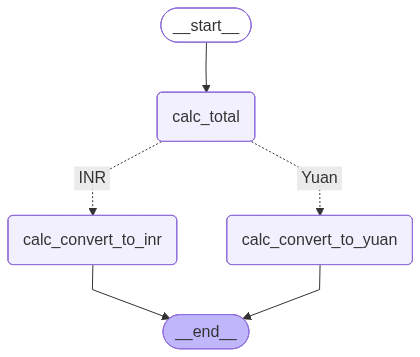

In [26]:
from langgraph.graph import StateGraph, START, END

builder = StateGraph(PortfolioState)
builder.add_node("calc_total", calc_total)
builder.add_node("calc_convert_to_inr", calc_convert_to_inr)
builder.add_node("calc_convert_to_yuan", calc_convert_to_yuan)
# builder.add_node("choose_conversion", choose_conversion)

builder.add_edge(START, "calc_total")
builder.add_conditional_edges("calc_total", choose_conversion,
 {
     'INR': "calc_convert_to_inr",
     'Yuan': "calc_convert_to_yuan"
     })
builder.add_edge(["calc_convert_to_inr", "calc_convert_to_yuan"], END)
builder.compile()

In [27]:
app = builder.compile()

# Test with INR as preferred currency
result_inr = app.invoke({"amountUSD": 100, "preferredCurrency": "INR"})
print("Result for INR:", result_inr)

# Test with Yuan as preferred currency
result_yuan = app.invoke({"amountUSD": 100, "preferredCurrency": "Yuan"})
print("Result for Yuan:", result_yuan)

Result for INR: {'amountUSD': 100, 'totalUSD': 103.0, 'preferredCurrency': 'INR', 'amount': 9500}
Result for Yuan: {'amountUSD': 100, 'totalUSD': 103.0, 'preferredCurrency': 'Yuan', 'amount': 684.0}
